In [1]:
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator

import gemmi 
import parasail
import numpy as np
from rdkit import Chem

from xaidar.data.molecModels import get_pdb_stats, sele_pdb, sele_Lig, get_res_CoM
from xaidar.data.molecModels import flatten_pdb, sele_AA, createPDB, get_atom_coord

- ## Load Proteins and Fragments of Interest

In [2]:
from xaidar.data.protocols import load_and_filter_Proteins, extract_lig_from_prot
from xaidar.data.molecModels import get_res_CoM, sele_pdb, sele_Lig, flatten_pdb, sele_closest_Chain, get_pdb_stats
# 1. Loading Fragalyis data Root Directory
rootProjDir = rootdir / "data/ev2a/fragalysis"
fragalysisDir =  rootdir / "data/ev2a/fragalysis"

# 2. Load Fragalysis Protein Directories
nonactivepdbs_dir = fragalysisDir / "02-chemofint/nonactivesite"
fragscreen_dir = fragalysisDir / "02-chemofint/fragscreen"
piperid_dir = fragalysisDir / "02-chemofint/piperid"
ref_dir = fragalysisDir / "02-chemofint/reference"

ref_obj = gemmi.read_pdb( str( next(ref_dir.glob( "??????.pdb" )) ) )
ref_lig = sele_pdb( ref_obj, sele_Lig )
lig_CoM = gemmi.Position( *get_res_CoM( flatten_pdb( ref_lig, "residue" ) )[0] )
ref_prot = sele_pdb( sele_pdb( ref_obj, sele_AA ), sele_closest_Chain, lig_CoM)


def process_lig_prot(pdb_dir: Path, ) -> dict:
    num_chains = None
    num_lig_chains = None # Number of chains with ligands
    if num_chains > 1 and num_lig_chains > 1:
        pass
    elif num_chains >1 and num_lig_chains == 1:
        pass
    elif num_chains == 1 and num_lig_chains ==1:
        pass

- ## Get Active Site Center of Mass

In [3]:
# Load Ligands from Piperid Datasets that are in the active site
ligs, ligs_datasets,  logs = extract_lig_from_prot( piperid_dir, coord = get_res_CoM( flatten_pdb( ref_lig, "residue" ) )[0] )

ligs_CoM = np.array([ np.array(get_res_CoM( flatten_pdb( lig, "residue") )[0]) if lig is not None else None for lig in ligs ])
mean_CoM = np.mean( ligs_CoM, axis = 0)

ligs_dist = [ np.linalg.norm( mean_CoM - lig_CoM ) for lig_CoM in ligs_CoM ]
standard_dataset_indexs = [ idx for idx, value in enumerate(ligs_dist) if value <= 5]
updated_mean_CoM = np.mean( [ ligs_CoM[idx] for idx in standard_dataset_indexs] , axis = 0)
# Update Ligands based on new CoM
ligs, ligs_datasets,  logs = extract_lig_from_prot( piperid_dir, coord = updated_mean_CoM )

ligs_res_lst = [ flatten_pdb( lig, "residue")[0] for lig in ligs ]



- ## Get Ground State Protein

In [4]:
# Load closests aa chain to mean CoM for Proteins without Active Site Labels 
from xaidar.data.protocols import load_and_filter_Proteins
nonactive_prots, nonactive_logs = load_and_filter_Proteins( nonactivepdbs_dir, 
                                                                    updated_mean_CoM )

1.160799655037218


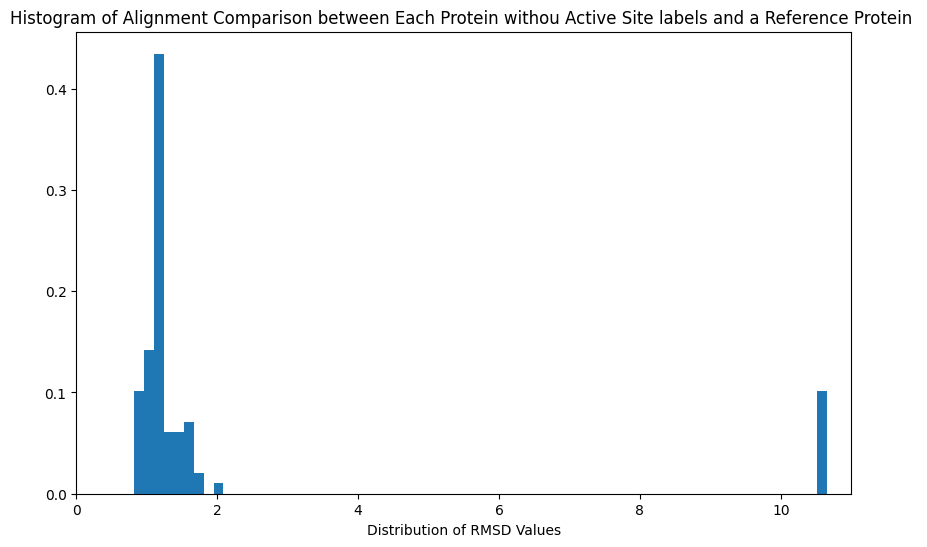

In [5]:
# Align all proteins without active site labels to reference protein
from xaidar.data.molecModels import structAlign
aligned_nonactive_prots = []
for prot in nonactive_prots:
    prot = structAlign( ref_prot, prot).calc_rmsd().align().aligned_prot
    aligned_nonactive_prots.append( prot)
# Get rmsd for proteins and ref protein
from xaidar.data.molecModels import structAlign
rmsd_logs = []
rmsd = structAlign( ref_prot, nonactive_prots[0]).calc_rmsd().rmsd
print(  rmsd)

for prot in nonactive_prots:
    rmsd_logs.append( structAlign( ref_prot, prot).calc_rmsd().rmsd )

import matplotlib.pyplot as plt
import numpy as np

plt.figure( figsize = [10, 6] )
bin = 70
plt.hist( rmsd_logs, bins = bin, weights = np.ones_like( np.array(rmsd_logs)) / len(rmsd_logs)  )
plt.xlabel( "Distribution of RMSD Values")
plt.title( "Histogram of Alignment Comparison between Each Protein withou Active Site labels and a Reference Protein ")
plt.xlim( 0, 11)
plt.show()


In [6]:
aligned_nonactive_prots = []
for prot in nonactive_prots:
    prot = structAlign( ref_prot, prot).calc_rmsd().align().aligned_prot
    aligned_nonactive_prots.append( prot)



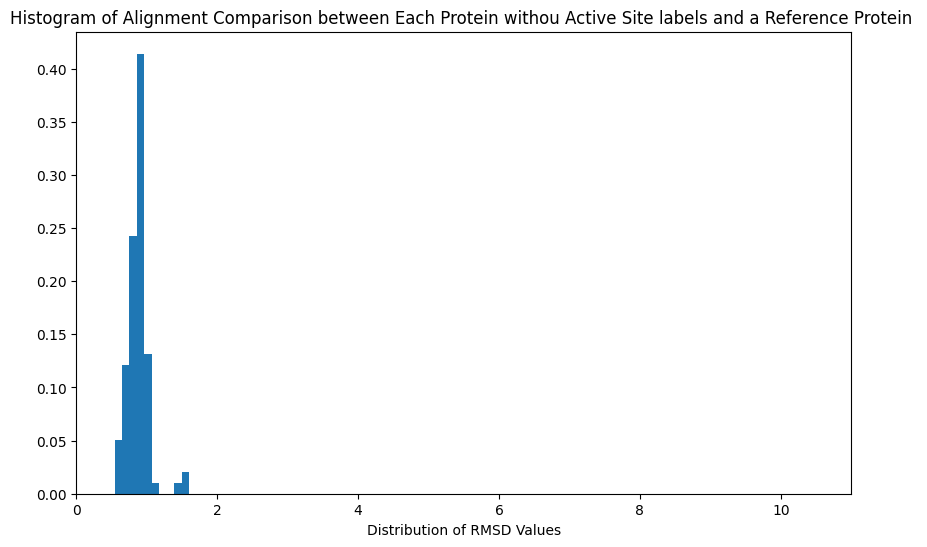

In [7]:
# Get rmsd for proteins and ref protein
from xaidar.data.molecModels import structAlign
rmsd_logs = []

for prot in aligned_nonactive_prots:
    rmsd_logs.append( structAlign( ref_prot, prot).calc_rmsd().rmsd )

import matplotlib.pyplot as plt
import numpy as np

plt.figure( figsize = [10, 6] )
bin = 10
plt.hist( rmsd_logs, bins = bin, weights = np.ones_like( np.array(rmsd_logs)) / len(rmsd_logs)  )
plt.xlabel( "Distribution of RMSD Values")
plt.title( "Histogram of Alignment Comparison between Each Protein withou Active Site labels and a Reference Protein ")
plt.xlim( 0, 11)
plt.show()